# 5.05 — Albert quantification of SRR3997504 (per-chromosome L1 aggregation)

Port of legacy `4.02-ach-albert_quantify_SRR3997504` into the R/ggplot reproducibility
scheme. **Stage A** (`.trap/scripts/aggregate_srr_by_chr.py srr3997504`, on Grace) produces
`results/srr3997504/aggregate_by_chr.csv` (`sample, figure, chrom, method, class, value`).
**Stage B** (this notebook) renders the four by-chromosome figures to
`reports/figures/srr3997504/`:

- **`SRR3997504_agreggate_mlvs_bowtie_by_chr`** — ML (Albert scores) vs Bowtie2 /
  RepeatMasker, unfiltered.
- **`SRR3997504_filtered_agreggate_mlvs_star_by_chr`** — ML (P(NEGATIVE) < 0.3) vs STAR of
  filtered reads vs STAR of all reads.
- **`SRR3997504_filtered_agreggate_l1em_mlvs_star_by_chr`** — adds L1EM (L1EM.400 intervals
  on the filtered STAR alignment).
- **`SRR3997504_filtered_agreggate_l1em_bwa_by_chr`** — ML vs L1EM re-aligned with BWA.

Classes: L1HS / L1PA2 / L1PA / LINE/L1. Combined "Method (Class)" legend inside the panel;
same data, axes, methods, and ordering as `notebooks/images/SRR3997504_*_by_chr.png`.


In [1]:
## Reproducibility & environment capture -------------------------------
set.seed(3469)
suppressPackageStartupMessages({
  library(data.table)
  library(ggplot2)
  library(jsonlite)
})
options(repr.plot.width = 12, repr.plot.height = 7)
theme_set(theme_bw(base_size = 28.125))


In [2]:
## Paths, provenance, palette ------------------------------------------
results_dir <- file.path("..", "results", "srr3997504")
figures_dir <- file.path("..", "reports", "figures", "srr3997504")
dir.create(figures_dir, recursive = TRUE, showWarnings = FALSE)
cat("results_dir:", results_dir, "\n")
cat("figures_dir:", figures_dir, "\n")

manifest_path <- file.path(results_dir, "manifest.json")
if (file.exists(manifest_path)) {
  manifest <- fromJSON(manifest_path)
  cat("\n-- compute manifest --\n")
  cat("git_commit:", manifest$git_commit, "\n")
  cat("timestamp: ", manifest$timestamp_utc, "\n")
  cat("seed:      ", manifest$seed, "\n")
  if (!is.null(manifest$seed)) stopifnot(manifest$seed == 3469)
} else {
  warning("manifest.json not found — run .trap/scripts/aggregate_srr_by_chr.py first.")
}

# The legacy figures encode subfamily CLASS by colour and quantification METHOD by fill
# pattern (solid / hatched / open), with a single combined "Method (Class)" legend inside the
# panel. Reproduce that with one fill series per (method, class): the class fixes the hue
# (fixed palette; red #D62728 reserved) and the method lightens it (primary method darkest).
class_palette <- c("L1HS" = "#1F77B4", "L1PA2" = "#FF7F0E", "L1PA" = "#2CA02C",
                   "LINE/L1" = "#9467BD", "NEGATIVE" = "#7F7F7F")
class_levels  <- names(class_palette)
chrom_levels  <- c(paste0("chr", 1:22), "chrX", "chrY", "chrMT", "chrM")

lighten <- function(hex, amount) {           # amount in [0,1]: 0 = base hue, 1 = white
  v <- col2rgb(hex) / 255
  v <- v + (1 - v) * amount
  grDevices::rgb(v[1], v[2], v[3])
}
series_palette <- function(methods, classes) {   # names "Method (Class)" -> colour
  amt <- if (length(methods) <= 1) 0 else seq(0, 0.62, length.out = length(methods))
  pal <- character(0)
  for (cl in classes) for (i in seq_along(methods))
    pal[sprintf("%s (%s)", methods[i], cl)] <- lighten(class_palette[[cl]], amt[i])
  pal
}

save_fig <- function(plot, stem, width = 12, height = 7) {
  for (ext in c("png", "pdf")) {
    f <- file.path(figures_dir, paste0(stem, ".", ext))
    suppressMessages(ggsave(f, plot, width = width, height = height, dpi = 300, bg = "white"))
  }
  invisible(plot)
}


results_dir: ../results/srr3997504 
figures_dir: ../reports/figures/srr3997504 

-- compute manifest --
git_commit: d2465ab6d07b598b48a626265a38e5ab59ebc315 
timestamp:  2026-07-05T01:23:26.394485+00:00 
seed:       3469 


In [3]:
## Load the tidy table + validation checks ----------------------------
agg_path <- file.path(results_dir, "aggregate_by_chr.csv")
stopifnot("aggregate_by_chr.csv not found — run the Stage-A translator" = file.exists(agg_path))
agg <- fread(agg_path)

req <- c("sample", "figure", "chrom", "method", "class", "value")
stopifnot("missing required columns" = all(req %in% names(agg)))
stopifnot("value must be finite and >= 0" = all(is.finite(agg$value) & agg$value >= 0))

std_chrom <- c(paste0("chr", 1:22), "chrX", "chrY", "chrMT", "chrM")
bad_chrom <- setdiff(unique(agg$chrom), std_chrom)
if (length(bad_chrom) > 0)
  warning(sprintf("non-standard chrom(s) present: %s", paste(bad_chrom, collapse = ", ")))

cat("Loaded", nrow(agg), "rows; figures:\n")
print(agg[, .N, by = figure])


Loaded 856 rows; figures:
                                                figure     N
                                                <char> <int>
1:             SRR3997504_agreggate_mlvs_bowtie_by_chr   150
2:       SRR3997504_filtered_agreggate_l1em_bwa_by_chr   120
3: SRR3997504_filtered_agreggate_l1em_mlvs_star_by_chr   336
4:      SRR3997504_filtered_agreggate_mlvs_star_by_chr   250


In [4]:
## Grouped-bar helper (per chromosome; combined Method (Class) legend) --
# One figure = one `figure` value. Bars are dodged per chromosome, ordered class-major /
# method-minor (legacy column order); the legend is method-major (legacy column order).
# fill = "Method (Class)" (class hue + method lightness). `legend`: "inside" (top-left, boxed —
# the 4.01-sourced 5.03 figures) or an outside keyword like "right" (the 4.02-sourced 5.04
# figures, whose combined legend is too wide to sit inside). Missing combos -> no bar.
plot_by_chr <- function(dt, stem, method_levels, legend = "inside",
                        legend_size = 18.75, width = 12, height = 7) {
  d <- dt[figure == stem]
  if (nrow(d) == 0) { warning(sprintf("%s: no rows — skipped", stem)); return(invisible(NULL)) }
  present <- intersect(method_levels, unique(d$method))
  if (length(present) < length(method_levels))
    warning(sprintf("%s: missing method(s): %s", stem,
                    paste(setdiff(method_levels, present), collapse = ", ")))
  classes <- intersect(class_levels, unique(d$class))

  d <- copy(d)
  d <- d[method %in% present & class %in% classes]
  d[, chrom := factor(chrom, levels = chrom_levels)]; d <- d[!is.na(chrom)]
  d[, series_chr := sprintf("%s (%s)", method, class)]

  # class-major dodge order; method-major legend order; keep only combos with data.
  have         <- unique(d$series_chr)
  dodge_levels <- as.vector(outer(present, classes, function(m, cl) sprintf("%s (%s)", m, cl)))
  legend_lvls  <- as.vector(outer(classes, present, function(cl, m) sprintf("%s (%s)", m, cl)))
  dodge_levels <- intersect(dodge_levels, have); legend_lvls <- intersect(legend_lvls, have)
  d[, series := factor(series_chr, levels = dodge_levels)]
  pal <- series_palette(present, classes)

  p <- ggplot(d, aes(chrom, value, fill = series, group = series)) +
    geom_col(position = position_dodge2(preserve = "single", padding = 0.1),
             colour = "grey30", linewidth = 0.1) +
    scale_fill_manual(values = pal, breaks = legend_lvls, name = NULL) +
    scale_y_continuous(expand = expansion(mult = c(0, 0.05))) +
    labs(x = NULL, y = "Aggregated L1 reads") +
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
          legend.key.size = unit(0.9, "lines"),
          legend.text = element_text(size = legend_size))
  if (identical(legend, "inside")) {
    p <- p + guides(fill = guide_legend(ncol = length(present))) +
      theme(legend.position = c(0.01, 0.99), legend.justification = c(0, 1),
            legend.background = element_rect(fill = alpha("white", 0.75), colour = NA),
            legend.margin = margin(2, 4, 2, 4))
  } else {                                    # outside (legacy 4.02): single column, e.g. "right"
    p <- p + guides(fill = guide_legend(ncol = 1)) + theme(legend.position = legend)
  }
  save_fig(p, stem, width, height)
  p
}


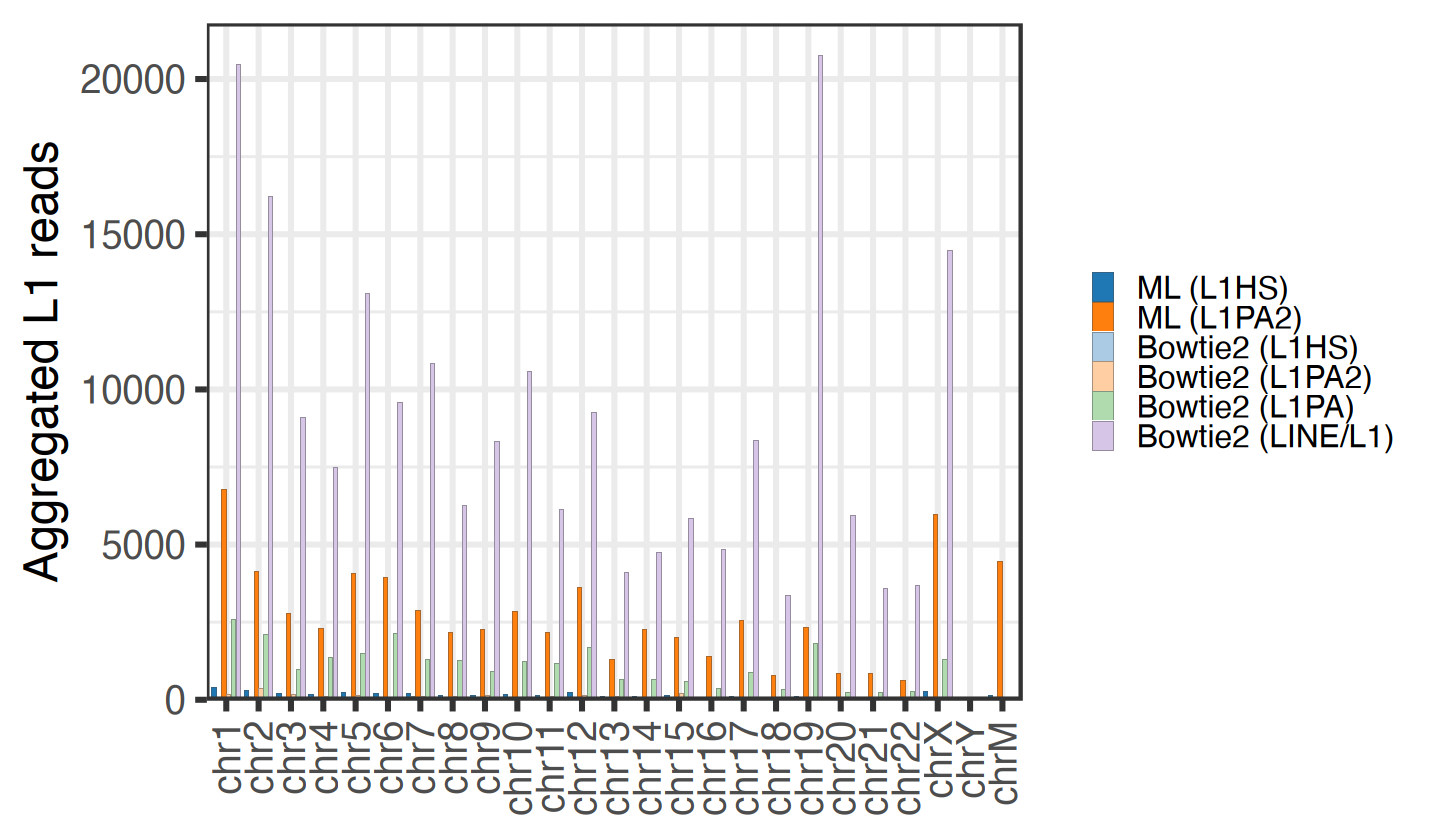

In [5]:
## ML (Albert) vs Bowtie2/RepeatMasker (unfiltered)
plot_by_chr(agg, "SRR3997504_agreggate_mlvs_bowtie_by_chr", method_levels = c("ML", "Bowtie2"), legend = "right", width = 14)


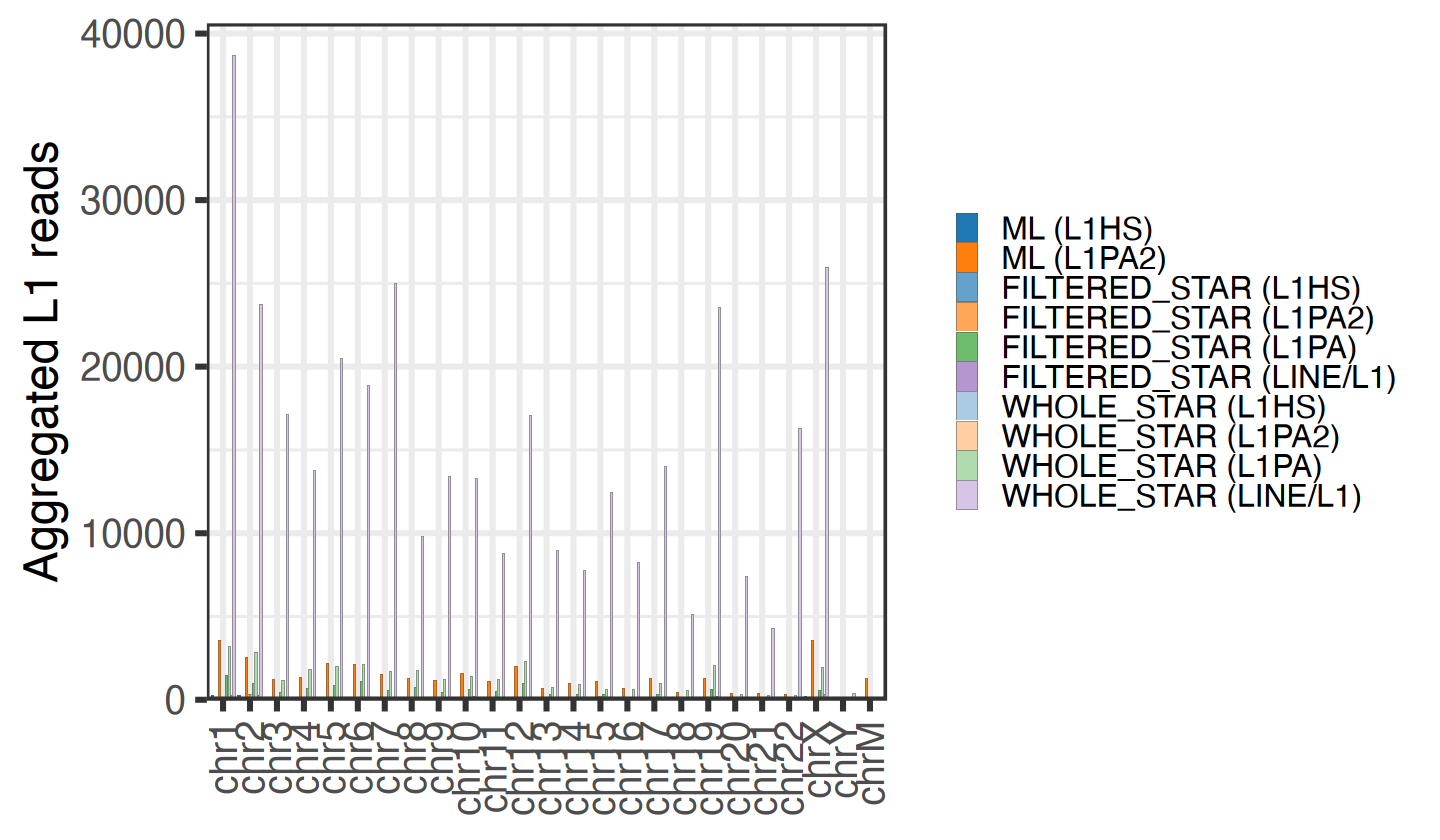

In [6]:
## ML (filtered) vs STAR filtered vs STAR whole
plot_by_chr(agg, "SRR3997504_filtered_agreggate_mlvs_star_by_chr", method_levels = c("ML", "FILTERED_STAR", "WHOLE_STAR"), legend = "right", width = 14)


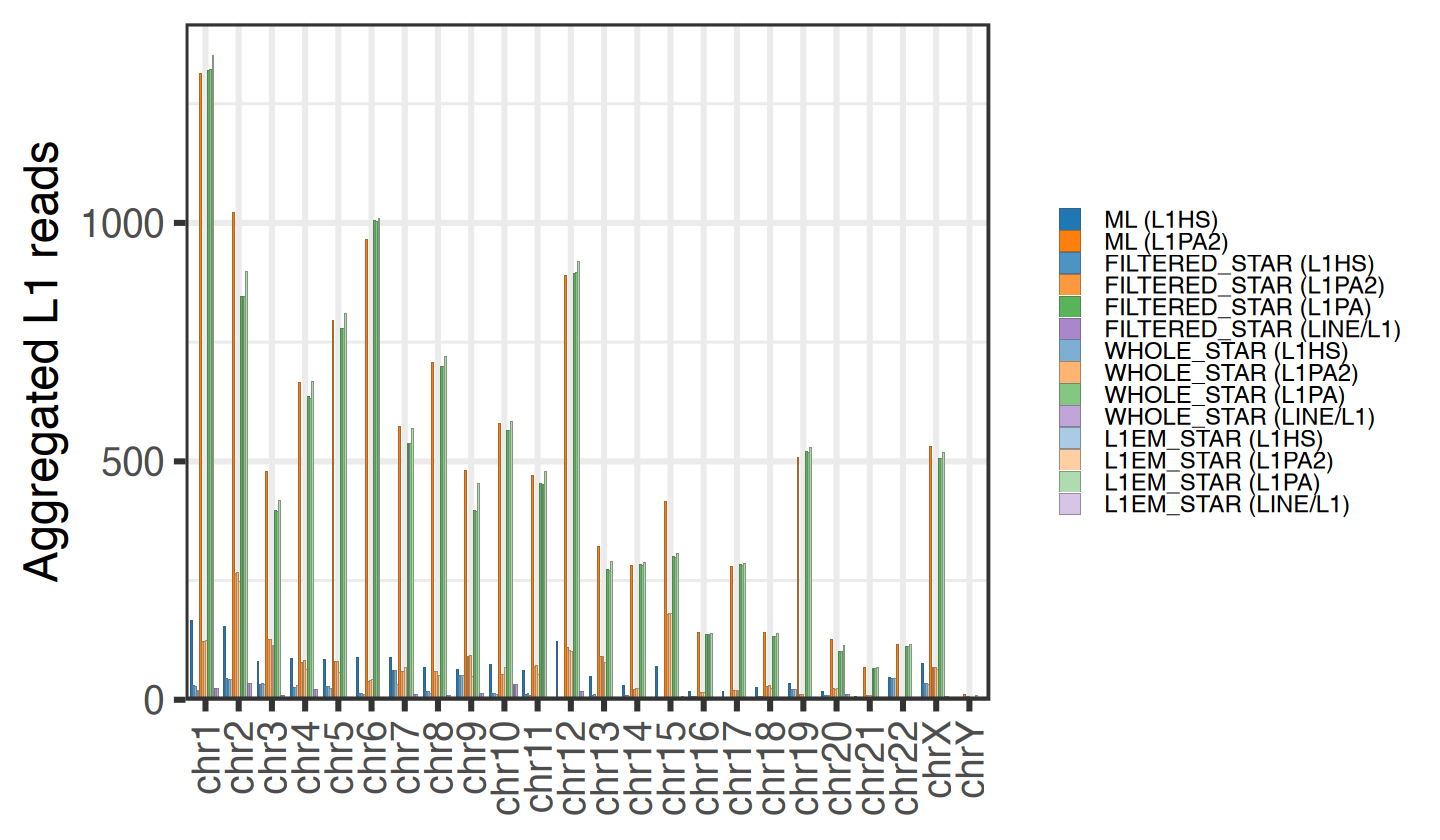

In [7]:
## + L1EM (L1EM.400 intervals on filtered STAR)
plot_by_chr(agg, "SRR3997504_filtered_agreggate_l1em_mlvs_star_by_chr", method_levels = c("ML", "FILTERED_STAR", "WHOLE_STAR", "L1EM_STAR"), legend = "right", legend_size = 14, width = 14)


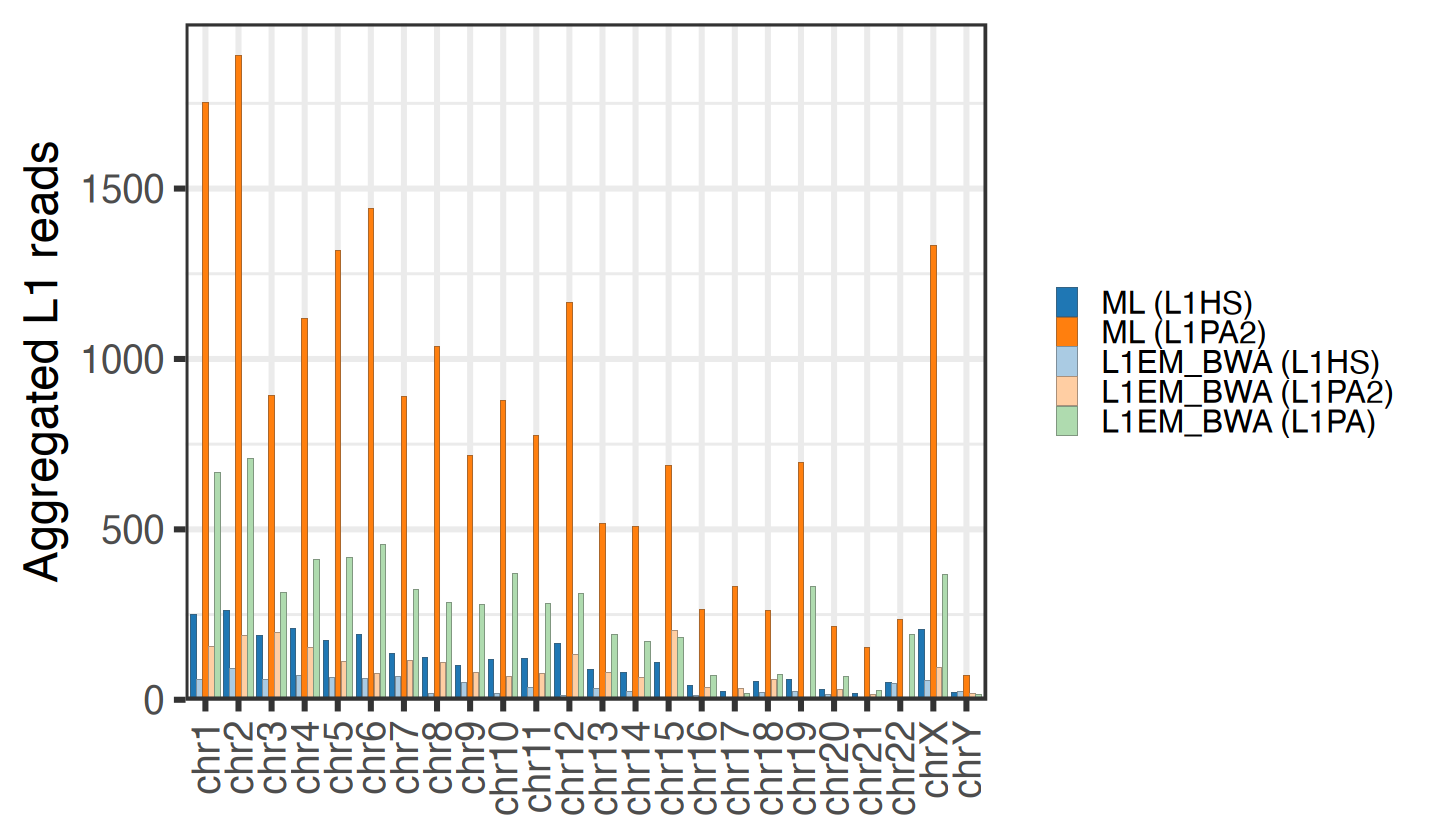

In [8]:
## ML vs L1EM (BWA re-alignment), aggregated by L1EM locus chromosome
plot_by_chr(agg, "SRR3997504_filtered_agreggate_l1em_bwa_by_chr", method_levels = c("ML", "L1EM_BWA"), legend = "right", width = 14)
